# Dynamic correlations between SPY and Bitcoin weekly returns

Exploratory notebook comparing weekly SPY and Bitcoin returns over time. The final plot uses faceted scatter plots with regression lines by year and quarter to inspect changes in the relationship between the two assets.


## Download and load data

In [ ]:
import pandas as pd
import numpy as np


In [6]:
import yfinance as yf

In [61]:
SP_500= yf.download('SPY',interval='1wk' )

[*********************100%***********************]  1 of 1 completed


In [1]:
Btc = pd.read_csv('BTCUSDT_1w_01-01-2017_15-04-2022.csv', parse_dates=True, index_col=0)
Btc.columns = Btc.columns.str.lower()
Btc.head()


NameError: name 'pd' is not defined

## Compute returns and merge datasets

In [87]:
Btc['Rets_weekly_Btc']= Btc['close'].pct_change()
Btc = Btc.filter(['Rets_weekly_Btc'])

In [88]:
SP_500['Rets_weekly_Sp']= SP_500['Close'].pct_change()
SP_500= SP_500.filter(['Rets_weekly_Sp'])
SP_500

KeyError: 'Close'

In [89]:
merge=pd.merge(SP_500,Btc, how='inner', left_index=True, right_index=True)

In [90]:
merge['Quarter']= merge.index.quarter

In [91]:
merge['Year']= merge.index.year

## Plot

In [92]:
import seaborn as sns

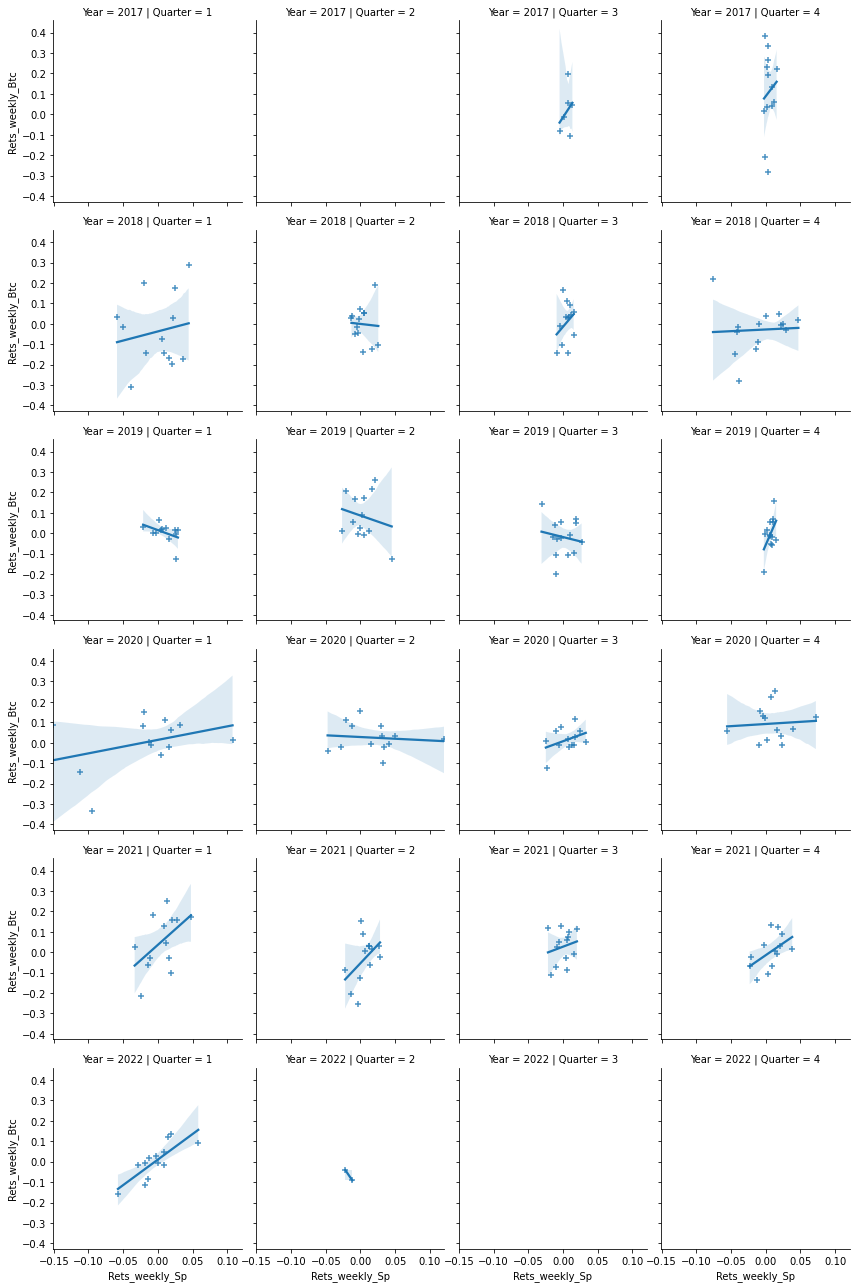

In [95]:
g = sns.FacetGrid(merge, col="Quarter", row='Year')

g.map(sns.regplot,'Rets_weekly_Sp','Rets_weekly_Btc',  marker="+")

In [96]:
merge.to_csv('SP_BTC_W_rets_mix.csv')